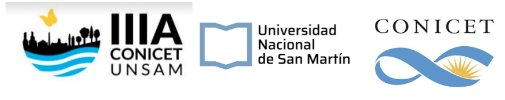  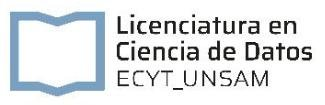

---

# NB07 — Procesos de puntos: del laboratorio al territorio

Lo que veremos en esta notebook:

- [x] Procesos de puntos: eventos como realización de una distribución espacial
- [x] Tres regímenes canónicos: CSR, agregación, regularidad — patrones de referencia
- [x] Intensidad y densidad: estimación kernel (KDE)
- [x] Completa aleatoriedad espacial (CSR) como hipótesis nula
- [x] Función G: distancia al vecino más cercano
- [x] Función K de Ripley y su transformación L
- [x] K cruzada: interacciones entre dos conjuntos de puntos
- [x] Aplicación: asentamientos RENABAP en el corredor norte-oeste del AMBA
- [x] K cruzada RENABAP × rezago educativo censal
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Distinguir la estadística de procesos de puntos de otras ramas de la estadística espacial.
- Reconocer visualmente los tres regímenes canónicos de un patrón puntual (aleatorio, agregado, regular) y leer sus firmas en las funciones $G$, $K$, $L$.
- Estimar una superficie de intensidad sobre un territorio con KDE, y discutir la sensibilidad al ancho de banda.
- Testear si un patrón observado es compatible con CSR usando envolventes Monte Carlo.
- Analizar interacciones entre dos conjuntos de puntos con la función K cruzada.
- Conectar la estructura espacial de los asentamientos precarios con variables censales del territorio.

### Datos con los que trabajaremos

- `data/raw_data/vectorial/RENABAP_20231205.gpkg` — Registro Nacional de Barrios Populares (RENABAP), polígonos de asentamientos precarios. Los convertimos a puntos usando sus centroides.
- `data/raw_data/vectorial/zona_estudio.geojson` — ventana del área de análisis (13 partidos del corredor noroeste del AMBA).
- `data/raw_data/vectorial/radios_censo_2022.gpkg` — radios censales del Censo 2022 (capa cruda del CONICET). La filtramos espacialmente con la zona de estudio.
- `data/raw_data/tablas/Indicadores de personas. Radios, 2022.csv` — variables de población por radio, incluyendo educación.

### Conexión con el arco del curso

Esta clase abre la rama de la estadística espacial dedicada a **localizaciones de eventos**: la pregunta deja de ser "cuánto vale esta variable en esta área" y pasa a ser "dónde están los eventos y por qué ahí". Es una mirada complementaria a las clases de datos areales (vulnerabilidad social, autocorrelación espacial).

El RENABAP es una fuente directamente vinculada a uno de los ejes territoriales que recorre el curso: los barrios populares son una materialización geográfica de la vulnerabilidad social. Su distribución espacial — si está agregada, si coincide con otros indicadores de carencia, si se aleja o acerca a cauces inundables — alimenta la lectura territorial que retomamos en las notebooks integradoras.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree

# pointpats >= 2.2 trae k_test con corrección de borde y envolvente CSR.
# En versiones anteriores la función puede llamarse distinto; si esta línea
# falla, revisar `pip install --upgrade pointpats`.
from pointpats import k_test

# osmnx solo lo usamos en el ejercicio opcional sobre cauces; lo importamos
# acá por comodidad.
import osmnx as ox

# contextily para basemaps OSM en las visualizaciones territoriales
try:
    import contextily as ctx
    CONTEXTILY_OK = True
except ImportError:
    CONTEXTILY_OK = False
    print('contextily no instalado: pip install contextily')

# Generador con semilla para los procesos sintéticos
rng = np.random.default_rng(42)

# Helper: cmap con canal alpha lineal (los valores bajos quedan transparentes,
# los altos opacos). Útil para superponer un KDE sobre un basemap.
def cmap_con_alpha(nombre_base, alpha_max=0.85):
    base = cm.get_cmap(nombre_base)
    colores = base(np.linspace(0, 1, 256))
    colores[:, -1] = np.linspace(0, alpha_max, 256)
    return LinearSegmentedColormap.from_list(f'{nombre_base}_alpha', colores)

RAW  = './data/raw_data/'
PROC = './data/proc/'

FN_RENABAP  = RAW  + 'vectorial/RENABAP_20231205.gpkg'
FN_ZONA     = RAW  + 'vectorial/zona_estudio.geojson'
FN_RADIOS_CRUDOS = RAW + 'vectorial/radios_censo_2022.gpkg'
FN_PERSONAS = RAW  + 'tablas/Indicadores de personas. Radios, 2022.csv'

---
# 1. Tres patrones canónicos

Antes de aplicar las herramientas a un problema concreto conviene calibrar el ojo con los tres regímenes que la literatura clásica usa como referencia:

| Régimen | Mecanismo típico | Ejemplo histórico |
|---|---|---|
| **CSR** (Completa Aleatoriedad Espacial) | Eventos independientes, intensidad constante | Pinos negros japoneses (Numata 1961) |
| **Agregación** | Atracción o cluster generador | Plántulas de secuoya alrededor de tocones (Strauss 1975; Ripley 1977) |
| **Regularidad** | Inhibición, competencia por espacio | Centros celulares (Ripley 1977) |

Estos tres datasets son canónicos en la literatura — aparecen en Diggle (2003) *Statistical Analysis of Spatial Point Patterns* y en Baddeley, Rubak & Turner (2015) *Spatial Point Patterns*. En vez de cargar los datos originales, los generamos sintéticamente con tres procesos estocásticos correspondientes:

- **CSR** $\sim$ proceso de Poisson homogéneo: ubicaciones uniformes independientes en la ventana.
- **Agregación** $\sim$ proceso de Thomas: centros padres CSR, hijos gaussianos alrededor de cada padre (caso particular del proceso de Neyman-Scott).
- **Regularidad** $\sim$ proceso de Matérn tipo II: thinning de un CSR con marcas temporales; un punto sobrevive solo si su marca es la mínima dentro de su disco de inhibición.

Trabajar con simulaciones tiene una ventaja didáctica importante: **conocemos la verdad**. Cuando más adelante apliquemos $G$, $K$ y $L$ a estos tres patrones vamos a poder calibrar cómo se ve cada estadístico bajo cada régimen, y solo entonces leer el caso real.

### Generadores

In [ ]:
def generar_csr(n, ventana, rng):
    """Proceso de Poisson homogéneo con n eventos en la ventana [xmin,ymin,xmax,ymax]."""
    xmin, ymin, xmax, ymax = ventana
    xs = rng.uniform(xmin, xmax, n)
    ys = rng.uniform(ymin, ymax, n)
    return np.column_stack([xs, ys])


def generar_thomas(n_padres, hijos_por_padre, sigma, ventana, rng):
    """Proceso de Thomas (caso de Neyman-Scott con kernel gaussiano).

    Cada padre genera hijos_por_padre ~ Poisson(hijos_por_padre) descendientes
    distribuidos como N(padre, sigma * I). Recortamos los hijos a la ventana.
    """
    xmin, ymin, xmax, ymax = ventana
    padres = generar_csr(n_padres, ventana, rng)
    hijos = []
    for px, py in padres:
        k = rng.poisson(hijos_por_padre)
        if k == 0:
            continue
        h = rng.normal(loc=[px, py], scale=sigma, size=(k, 2))
        # Mantenemos los hijos que caen dentro de la ventana
        h = h[(h[:, 0] >= xmin) & (h[:, 0] <= xmax) &
              (h[:, 1] >= ymin) & (h[:, 1] <= ymax)]
        hijos.append(h)
    return np.vstack(hijos) if hijos else np.empty((0, 2))


def generar_matern_ii(intensidad, radio_inhib, ventana, rng, oversample=3):
    """Proceso de Matérn tipo II (thinning con marcas temporales).

    Generamos un CSR sobreabundante (intensidad * area * oversample puntos),
    asignamos a cada uno una marca uniforme [0,1], y aceptamos un punto solo
    si su marca es la mínima entre las marcas de todos los candidatos dentro
    de un disco de radio `radio_inhib`. Esto produce un patrón regular: dos
    puntos aceptados nunca están a distancia menor que radio_inhib.
    """
    xmin, ymin, xmax, ymax = ventana
    area = (xmax - xmin) * (ymax - ymin)
    n_inicial = int(intensidad * area * oversample)
    candidatos = generar_csr(n_inicial, ventana, rng)
    marcas = rng.uniform(size=len(candidatos))
    tree = cKDTree(candidatos)
    aceptados = []
    for i, xy in enumerate(candidatos):
        vecinos = tree.query_ball_point(xy, radio_inhib)
        if all(marcas[i] <= marcas[j] for j in vecinos):
            aceptados.append(xy)
    return np.array(aceptados) if aceptados else np.empty((0, 2))

### Generación y visualización lado a lado

Elegimos parámetros para que los tres procesos tengan cantidades comparables de puntos (~100–150 cada uno) en una ventana cuadrada $[0, 100]^2$. La elección no es crítica — lo importante es ver el contraste.

In [ ]:
ventana = (0.0, 0.0, 100.0, 100.0)

# Tres patrones canónicos
pts_csr      = generar_csr(n=120, ventana=ventana, rng=rng)
pts_cluster  = generar_thomas(n_padres=15, hijos_por_padre=8, sigma=3.0,
                               ventana=ventana, rng=rng)
pts_regular  = generar_matern_ii(intensidad=0.012, radio_inhib=5.0,
                                  ventana=ventana, rng=rng)

print(f'CSR        : {len(pts_csr):4d} puntos')
print(f'Thomas     : {len(pts_cluster):4d} puntos')
print(f'Matérn II  : {len(pts_regular):4d} puntos')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.set_facecolor('white')
for ax, pts, titulo in zip(
        axes,
        [pts_csr, pts_cluster, pts_regular],
        ['CSR (Poisson homogéneo)', 'Agregación (Thomas)', 'Regularidad (Matérn II)']):
    ax.scatter(pts[:, 0], pts[:, 1], s=18, color='black', alpha=0.75)
    ax.set_aspect('equal')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(f'{titulo}\nn = {len(pts)}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

La diferencia visual es inmediata: el patrón CSR muestra heterogeneidad aparente (zonas más densas que otras) que es producto del azar muestral, no de un mecanismo; el patrón agregado forma cúmulos compactos; el patrón regular muestra una distribución casi reticular. **El ojo entrenado reconoce estos regímenes; el resto de la clase formaliza ese reconocimiento.**

---
# 2. Intensidad: superficie de densidad con KDE

La **intensidad** $\lambda(s)$ de un proceso de puntos es la tasa esperada de eventos por unidad de área en la posición $s$. Es análoga a la densidad de una variable aleatoria pero definida en el plano.

La estimación kernel estándar es:

$$\hat{\lambda}(s) = \frac{1}{h^2} \sum_{i=1}^n K\left(\frac{s - x_i}{h}\right)$$

donde $K$ es un kernel (típicamente gaussiano) y $h$ es el **ancho de banda**, que controla el grado de suavizado.

**Elección del ancho de banda.** Es la decisión crítica del KDE. Ancho chico produce un mapa con picos agudos (posible sobreajuste). Ancho grande suaviza en exceso y oculta estructura. Reglas automáticas como la de Scott o Silverman son razonables para empezar, pero conviene iterar.

## 2.1 KDE sobre los tres patrones canónicos

Antes de aplicar KDE al territorio real, lo aplicamos a los tres patrones sintéticos para ver cómo se ve la intensidad estimada en cada régimen.

In [ ]:
def kde_grid(pts, ventana, res, bw_method='scott'):
    """Evalúa un KDE gaussiano sobre una grilla regular dentro de la ventana."""
    kde = gaussian_kde(pts.T, bw_method=bw_method)
    xmin, ymin, xmax, ymax = ventana
    xs = np.arange(xmin, xmax + res, res)
    ys = np.arange(ymin, ymax + res, res)
    XX, YY = np.meshgrid(xs, ys)
    Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    return XX, YY, Z


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.set_facecolor('white')
for ax, pts, titulo in zip(
        axes,
        [pts_csr, pts_cluster, pts_regular],
        ['CSR', 'Agregación', 'Regularidad']):
    _, _, Z = kde_grid(pts, ventana, res=1.0, bw_method='scott')
    im = ax.imshow(Z, extent=(0, 100, 0, 100), origin='lower', cmap='hot')
    ax.scatter(pts[:, 0], pts[:, 1], s=5, color='cyan', alpha=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Tres observaciones importantes:

1. **El KDE sobre un patrón CSR no es plano.** Aunque la *verdadera* intensidad del proceso es constante, la realización particular tiene fluctuaciones muestrales que el KDE recoge. Esto es una trampa pedagógica: ver picos en un mapa de KDE **no** implica que haya estructura — siempre hay que comparar con la variación esperable bajo CSR.

2. **El patrón agregado se ve "obvio" en el KDE**, con focos bien marcados que recuperan los centros padres del proceso de Thomas.

3. **El patrón regular pinta un mapa más uniforme** que el CSR, paradójicamente. La inhibición elimina las concentraciones azarosas y deja un campo más plano. Un KDE "demasiado parejo" puede ser firma de regularidad.

## 2.2 Sensibilidad al ancho de banda

Aplicamos KDE al patrón agregado con dos anchos de banda muy distintos para ver el efecto sobre la lectura.

In [ ]:
kde_scott = gaussian_kde(pts_cluster.T, bw_method='scott')
kde_grueso = gaussian_kde(pts_cluster.T, bw_method=1.0)  # factor mayor que Scott

# Interpretación física: el bandwidth efectivo en cada eje es el factor
# multiplicado por el desvío de los datos en ese eje.
sigma_x = pts_cluster[:, 0].std()
sigma_y = pts_cluster[:, 1].std()
sigma_medio = np.sqrt(sigma_x * sigma_y)

print(f'Desvío geográfico medio de los puntos: ~{sigma_medio:,.1f}')
print(f'Bandwidth efectivo Scott :  ~{kde_scott.factor  * sigma_medio:,.1f}')
print(f'Bandwidth efectivo grueso:  ~{kde_grueso.factor * sigma_medio:,.1f}')

xmin, ymin, xmax, ymax = ventana
xs = np.arange(xmin, xmax + 1, 1.0)
ys = np.arange(ymin, ymax + 1, 1.0)
XX, YY = np.meshgrid(xs, ys)
grid = np.vstack([XX.ravel(), YY.ravel()])

Z_scott  = kde_scott(grid).reshape(XX.shape)
Z_grueso = kde_grueso(grid).reshape(XX.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.set_facecolor('white')
for ax, Z, titulo in [(axes[0], Z_scott,  'KDE — ancho de banda Scott'),
                       (axes[1], Z_grueso, 'KDE — ancho de banda grueso (factor 1.0)')]:
    im = ax.imshow(Z, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='hot')
    ax.scatter(pts_cluster[:, 0], pts_cluster[:, 1], s=4, color='cyan')
    ax.set_title(titulo, fontsize=11)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

El KDE con ancho chico recupera los focos individuales del proceso (cada centro padre se ve como un pico). El KDE con ancho grueso suaviza esa estructura y produce un mapa que se parece más a una "densidad regional". La decisión depende de la pregunta: para identificar agrupamientos puntuales conviene un ancho intermedio; para mapear gradientes territoriales más amplios, un ancho mayor.

---
# 3. CSR como hipótesis nula

Para decidir si un patrón observado tiene estructura "interesante" necesitamos un punto de comparación: una hipótesis nula de aleatoriedad. En procesos de puntos el estándar es **Complete Spatial Randomness (CSR)**, también llamado proceso de Poisson homogéneo:

1. La cantidad de puntos en cualquier región $A$ se distribuye como $\text{Poisson}(\lambda |A|)$, donde $\lambda$ es la intensidad (constante) y $|A|$ es el área.
2. Condicionalmente al número de puntos, sus ubicaciones son uniformes independientes en el espacio.

Bajo CSR los puntos están "distribuidos al azar". Las desviaciones respecto de CSR tienen interpretaciones específicas:

| Observación | Interpretación |
|---|---|
| Más puntos juntos que CSR | **Agregación** (clustering) — hay mecanismos que los atraen al mismo lugar |
| Menos puntos juntos que CSR | **Inhibición** o regularidad — hay mecanismos que los separan |
| Como CSR | El patrón es consistente con completa aleatoriedad |

Los mecanismos de agregación e inhibición pueden ser **de primer orden** (variaciones en la intensidad a gran escala por heterogeneidad del territorio: cierto tipo de suelo solo está disponible en ciertas zonas) o **de segundo orden** (interacciones genuinas entre puntos: árboles que compiten por agua tienden a separarse). Las funciones que veremos a continuación —$G$, $K$, $L$— miden estas desviaciones desde ángulos complementarios.

**Test de Monte Carlo.** En la práctica, en vez de comparar contra una expresión analítica para $G$ o $K$ bajo CSR, simulamos muchos patrones CSR sobre la misma ventana, calculamos la estadística en cada uno, y construimos una **envolvente** empírica (los percentiles 2.5 y 97.5 dan una banda de confianza al 95%). Si la curva observada cae fuera de la envolvente a alguna escala $r$, rechazamos CSR a esa escala.

---
# 4. Función G: distancia al vecino más cercano

La **función G** es la distribución acumulada de la distancia entre cada evento y su vecino más cercano:

$$G(r) = P(\text{distancia al vecino más cercano} \leq r)$$

Bajo CSR de intensidad $\lambda$ se conoce la forma analítica:

$$G_\text{CSR}(r) = 1 - \exp(-\lambda \pi r^2)$$

Reglas de lectura:

| Posición de $\hat G(r)$ respecto de la envolvente CSR | Interpretación |
|---|---|
| **Por encima** | Hay más distancias cortas de lo esperado → agregación |
| **Por debajo** | Hay menos distancias cortas de lo esperado → regularidad / inhibición |
| **Dentro** | Consistente con CSR |

$G$ es la función más intuitiva del análisis de procesos puntuales y la primera que se propuso (Diggle 2003 lo discute en detalle). Su ventaja es que mira la **escala más fina** del patrón (vecinos inmediatos); su limitación es que ignora la estructura a escalas mayores que la distancia al primer vecino. Las funciones $K$ y $L$ que veremos después complementan esa información.

## 4.1 Estimador y envolvente

In [ ]:
def g_empirica(pts, r_vals):
    """ECDF de la distancia al vecino más cercano, evaluada en r_vals."""
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)  # k=2 porque k=1 devuelve el punto mismo
    dnn = d[:, 1]
    G = np.array([np.mean(dnn <= r) for r in r_vals])
    return G, dnn


def g_envolvente_csr(n, ventana, r_vals, n_sims, rng):
    """Envolvente de G bajo CSR: simulamos n_sims patrones CSR con n puntos en
    la ventana y calculamos G en cada uno."""
    sims = np.zeros((n_sims, len(r_vals)))
    for s in range(n_sims):
        pts = generar_csr(n, ventana, rng)
        sims[s], _ = g_empirica(pts, r_vals)
    return sims

## 4.2 G sobre los tres patrones canónicos

Calibramos el ojo: graficamos $\hat G(r)$ y la envolvente CSR sobre los tres patrones.

In [ ]:
r_vals_can = np.linspace(0, 10, 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.set_facecolor('white')
for ax, pts, titulo in zip(
        axes,
        [pts_csr, pts_cluster, pts_regular],
        ['CSR', 'Agregación (Thomas)', 'Regularidad (Matérn II)']):
    G_obs, _ = g_empirica(pts, r_vals_can)
    sims = g_envolvente_csr(len(pts), ventana, r_vals_can, n_sims=99, rng=rng)
    G_lo = np.percentile(sims, 2.5, axis=0)
    G_hi = np.percentile(sims, 97.5, axis=0)
    G_mean = sims.mean(axis=0)
    ax.fill_between(r_vals_can, G_lo, G_hi, alpha=0.25, color='gray',
                     label='Envolvente CSR 95%')
    ax.plot(r_vals_can, G_mean, '--', color='gray', label='G esperada bajo CSR')
    ax.plot(r_vals_can, G_obs, '-', color='red', lw=2, label='G observada')
    ax.set_xlabel('r')
    ax.set_ylabel('G(r)')
    ax.set_title(titulo, fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Lectura: en CSR la curva observada cae dentro de la envolvente; en agregación queda **por encima** (muchos vecinos a corta distancia, porque los puntos están en cúmulos); en regularidad queda **por debajo** (no hay vecinos a distancias chicas, la inhibición las prohíbe).

Estas tres firmas son las que vamos a buscar después en el dato real.

---
# 5. Función K de Ripley

Ripley (1976) definió:

$$K(r) = \lambda^{-1} \mathbb{E}[\text{\# eventos adicionales en un disco de radio } r \text{ desde un evento típico}]$$

A diferencia de $G$, que solo mira el primer vecino, $K(r)$ acumula información sobre **todos** los pares de eventos a distancia $\leq r$. Eso la hace más informativa a escalas grandes pero también más sensible a la corrección de borde.

El estimador habitual, con corrección de borde, es:

$$\hat{K}(r) = \frac{|A|}{n(n-1)} \sum_{i \neq j} w_{ij}\, \mathbf{1}(d_{ij} < r)$$

donde $|A|$ es el área de la región, $n$ el número de eventos, $d_{ij}$ la distancia entre el par $(i,j)$ y $w_{ij}$ una corrección de borde (típicamente la inversa de la proporción del círculo de radio $d_{ij}$ alrededor del evento $i$ que cae dentro de la ventana).

Bajo CSR, $K(r) = \pi r^2$. Por eso se suele graficar la **función L transformada**:

$$L(r) = \sqrt{K(r)/\pi} - r$$

Así CSR corresponde a $L(r) \equiv 0$. Valores positivos de $L(r)$ indican agregación a esa escala; negativos, inhibición.

La significancia se evalúa por Monte Carlo, igual que con $G$.

## 5.1 Implementación con `pointpats`

`pointpats.k_test` estima $K$ con corrección de borde y construye la envolvente bajo CSR simulando dentro de la *hull* de los puntos. Una advertencia práctica: `k_test` paraleliza las simulaciones con `joblib` y usa un generador aleatorio interno que no está controlado por la semilla global de NumPy. Eso significa que **los percentiles 2.5 y 97.5 de la envolvente van a variar levemente entre corridas** (típicamente menos del 1% del valor de $L$). El patrón cualitativo es estable; los gráficos no son bit a bit idénticos.

In [ ]:
def calcular_L(pts, r_vals, n_sims=99):
    """Wrapper sobre pointpats.k_test que devuelve L(r) y la matriz de L
    simuladas bajo CSR.

    Notar que pointpats.k_test no expone parámetro de semilla y usa un RNG
    interno, así que las simulaciones varían levemente entre corridas.
    """
    res = k_test(pts, support=r_vals, keep_simulations=True,
                 n_simulations=n_sims)
    L_obs  = np.sqrt(res.statistic / np.pi) - r_vals
    L_sims = np.sqrt(np.array(res.simulations) / np.pi) - r_vals
    return L_obs, L_sims

## 5.2 L sobre los tres patrones canónicos

In [ ]:
r_vals_can = np.linspace(0.5, 30, 35)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.set_facecolor('white')
for ax, pts, titulo in zip(
        axes,
        [pts_csr, pts_cluster, pts_regular],
        ['CSR', 'Agregación (Thomas)', 'Regularidad (Matérn II)']):
    L_obs, L_sims = calcular_L(pts, r_vals_can, n_sims=99)
    L_lo = np.percentile(L_sims, 2.5, axis=0)
    L_hi = np.percentile(L_sims, 97.5, axis=0)
    L_mean = L_sims.mean(axis=0)
    ax.fill_between(r_vals_can, L_lo, L_hi, alpha=0.25, color='gray',
                     label='Envolvente CSR 95%')
    ax.plot(r_vals_can, L_mean, '--', color='gray', label='L esperada bajo CSR')
    ax.plot(r_vals_can, L_obs, '-', color='red', lw=2, label='L observada')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('r')
    ax.set_ylabel(r'$L(r) = \sqrt{K(r)/\pi} - r$')
    ax.set_title(titulo, fontsize=11)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Las firmas son nítidas:

- **CSR**: $L$ oscila alrededor de cero dentro de la envolvente.
- **Agregación**: $L$ sube fuerte y se mantiene por encima de la envolvente en un rango amplio de $r$. La **escala** donde $L$ se maximiza es informativa: aproxima el tamaño típico del cúmulo.
- **Regularidad**: $L$ baja por debajo de la envolvente en distancias cortas (sin pares a corta distancia) y vuelve hacia cero a escalas mayores que el radio de inhibición.

**$G$ vs $L$ — ¿por qué dos funciones?** $G$ mira solo al vecino más cercano y por eso solo "ve" la escala más fina del patrón. $L$ acumula sobre todos los pares y ve todas las escalas $r$ donde uno mire. Para un patrón con cúmulos grandes pero ralos, $G$ puede dar señal débil (el vecino más cercano puede estar lejos) mientras que $L$ marca claramente la agregación. Para un patrón con regularidad estricta a corta escala pero indistinguible de CSR a escalas mayores, $G$ es más sensible. **Las dos juntas dan una lectura más completa que cualquiera por separado.**

---
# 6. Aplicación: asentamientos RENABAP en el corredor norte-oeste

El RENABAP es el registro oficial de barrios populares de Argentina. Los polígonos identifican asentamientos con características específicas: precariedad de las viviendas, ausencia o irregularidad en la provisión de servicios públicos, situación dominial irregular de la tierra.

Para los análisis de procesos de puntos trabajamos con **centroides**: convertimos cada asentamiento en un único punto. Esto es una simplificación — un asentamiento de 50 hectáreas no es un evento puntual. Para análisis exploratorio es aceptable, pero para análisis formales habría que usar herramientas de procesos en áreas o ponderar los centroides por superficie. Una regla de pulgar: si el tamaño típico del asentamiento ($\sqrt{\text{área media}}$) es comparable o mayor a la escala $r$ de análisis, la aproximación puntual se vuelve problemática. Lo calculamos abajo.

In [ ]:
gdf_renabap = gpd.read_file(FN_RENABAP)
gdf_zona    = gpd.read_file(FN_ZONA)

# Proyectamos todo a UTM 21S para distancias métricas
gdf_renabap = gdf_renabap.to_crs('EPSG:32721')
gdf_zona    = gdf_zona.to_crs('EPSG:32721')

# Recortamos RENABAP a la zona de estudio
gdf_renabap = gpd.overlay(gdf_renabap, gdf_zona, how='intersection')
print(f'Asentamientos en el área: {len(gdf_renabap)}')

# Tamaño típico de un asentamiento
areas = gdf_renabap.geometry.area
escala_tipica = np.sqrt(areas.median())
print(f'Área mediana                : {areas.median()/10_000:.2f} ha')
print(f'Escala lineal típica       : ~{escala_tipica:.0f} m')
print('(Si analizamos a escalas r menores que esto, la aproximación puntual pierde precisión.)')

# Centroides (uso de centroid es correcto acá: los asentamientos son razonablemente
# convexos y el centroide es un buen representante para el análisis estadístico)
gdf_renabap['centroide'] = gdf_renabap.geometry.centroid
puntos = gdf_renabap.set_geometry('centroide')

In [ ]:
# Visualización inicial
fig, ax = plt.subplots(figsize=(10, 9))
fig.set_facecolor('white')
gdf_zona.boundary.plot(ax=ax, color='black', linewidth=1)
gdf_renabap.plot(ax=ax, color='red', alpha=0.4, edgecolor='darkred')
puntos.plot(ax=ax, color='red', markersize=6)
ax.set_title(f'RENABAP en el corredor noroeste — {len(puntos)} asentamientos',
              fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6.1 KDE y sensibilidad al ancho de banda sobre RENABAP

In [ ]:
coords = np.array([(p.x, p.y) for p in puntos.geometry])

kde_fino   = gaussian_kde(coords.T, bw_method=0.1)
kde_scott  = gaussian_kde(coords.T, bw_method='scott')
kde_grueso = gaussian_kde(coords.T, bw_method=1.0)

# Bandwidth efectivo en metros: factor por desvío de los datos
sigma_x = coords[:, 0].std()
sigma_y = coords[:, 1].std()
sigma_medio = np.sqrt(sigma_x * sigma_y)

print(f'Desvío geográfico medio: ~{sigma_medio:,.0f} m')
print(f'Bandwidth efectivo fino  : ~{kde_fino.factor   * sigma_medio:,.0f} m')
print(f'Bandwidth efectivo Scott : ~{kde_scott.factor  * sigma_medio:,.0f} m')
print(f'Bandwidth efectivo grueso: ~{kde_grueso.factor * sigma_medio:,.0f} m')

# Grilla
xmin, ymin, xmax, ymax = gdf_zona.total_bounds
res = 250  # metros por celda
xs = np.arange(xmin, xmax, res)
ys = np.arange(ymin, ymax, res)
XX, YY = np.meshgrid(xs, ys)
grid = np.vstack([XX.ravel(), YY.ravel()])

Z_fino   = kde_fino(grid).reshape(XX.shape)
Z_scott  = kde_scott(grid).reshape(XX.shape)
Z_grueso = kde_grueso(grid).reshape(XX.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.set_facecolor('white')
cmap_kde = cmap_con_alpha('hot', alpha_max=0.85)

paneles = [
    (axes[0], Z_fino,   'KDE — ancho de banda fino (factor 0.1)'),
    (axes[1], Z_scott,  'KDE — ancho de banda Scott'),
    (axes[2], Z_grueso, 'KDE — ancho de banda grueso (factor 1.0)'),
]

for ax, Z, titulo in paneles:
    # Basemap primero (queda abajo)
    if CONTEXTILY_OK:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ctx.add_basemap(ax, crs='EPSG:32721',
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        attribution_size=6)
    # KDE encima con transparencia (los ceros quedan invisibles)
    im = ax.imshow(Z, extent=[xmin, xmax, ymin, ymax],
                    origin='lower', cmap=cmap_kde)
    gdf_zona.boundary.plot(ax=ax, color='black', linewidth=0.8)
    puntos.plot(ax=ax, color='cyan', markersize=3,
                 edgecolor='black', linewidth=0.3)
    ax.set_title(titulo)
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.show()

La sensibilidad al ancho de banda es visualmente dramática, y los tres regímenes muestran lecturas distintas del mismo dato:

- **Ancho fino (factor 0.1):** se distinguen claramente múltiples aglomeraciones locales — racimos a escala de barrio o de subzona urbana — repartidos por el corredor (norte, centro y sur). Cada foco corresponde a una concentración real de asentamientos. Esta es la escala más informativa para identificar "dónde están los problemas".
- **Ancho Scott (regla automática):** los racimos locales se funden en dos o tres manchas grandes que cubren los partidos centrales del área. Se gana suavidad pero se pierde la distinción entre nodos territorialmente distintos.
- **Ancho grueso (factor 1.0):** una sola superficie suave con un máximo central; el detalle territorial desaparece casi por completo. A esta escala el KDE se vuelve más un "centro de masa con dispersión" que un mapa de aglomeraciones.

La moraleja es que la regla automática (Scott) no siempre es la mejor opción: subsuaviza el dato cuando el fenómeno tiene estructura a múltiples escalas, como acá. Una práctica honesta es probar varios anchos y elegir el que muestra estructura sin caer en sobreajuste. En este caso el factor 0.1 es el más informativo; abajo lo confirmamos comparando con las funciones $G$ y $L$, que dan medidas cuantitativas de esa agregación que el ojo ya detecta.

## 6.2 Funciones G y L sobre RENABAP

**Una advertencia metodológica antes de leer los resultados.** La hipótesis CSR asume intensidad constante en toda la ventana. RENABAP es claramente inhomogéneo: hay grandes zonas rurales del corredor donde por definición no puede haber asentamientos informales (no hay urbanización, no hay tierra ociosa periurbana, etc.). Lo que vamos a calcular va a leer parte de esa heterogeneidad estructural como "agregación", aunque sea simplemente la sombra del soporte irregular del proceso. El ejercicio opcional al final aborda esto con la K inhomogénea (Baddeley, Møller & Waagepetersen 2000). Lo que sigue, entonces, hay que leerlo como "agregación marginal sobre la ventana cuadrada", no como "agregación intrínseca del proceso".

In [ ]:
xy = coords  # ya las tenemos como array (n, 2)

# Escalas de análisis: G a corta escala (hasta 5 km),
# L a escala media (100 m a 5 km).
r_vals_g = np.linspace(50, 5000, 50)
r_vals_l = np.linspace(100, 5000, 30)

# G empírica y envolvente CSR sobre la ventana rectangular del corredor
ventana_renabap = tuple(gdf_zona.total_bounds)
G_obs, _ = g_empirica(xy, r_vals_g)
G_sims = g_envolvente_csr(len(xy), ventana_renabap, r_vals_g,
                           n_sims=99, rng=rng)
G_lo = np.percentile(G_sims, 2.5, axis=0)
G_hi = np.percentile(G_sims, 97.5, axis=0)

# L con pointpats (corrige borde mejor que la envolvente rectangular para G)
L_obs, L_sims = calcular_L(xy, r_vals_l, n_sims=99)
L_lo = np.percentile(L_sims, 2.5, axis=0)
L_hi = np.percentile(L_sims, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.set_facecolor('white')

ax = axes[0]
ax.fill_between(r_vals_g, G_lo, G_hi, alpha=0.25, color='gray',
                 label='Envolvente CSR 95%')
ax.plot(r_vals_g, G_sims.mean(axis=0), '--', color='gray',
        label='G esperada bajo CSR')
ax.plot(r_vals_g, G_obs, '-', color='red', lw=2, label='G observada')
ax.set_xlabel('r (metros)')
ax.set_ylabel('G(r)')
ax.set_title('Función G — asentamientos RENABAP')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(r_vals_l, L_lo, L_hi, alpha=0.25, color='gray',
                 label='Envolvente CSR 95%')
ax.plot(r_vals_l, L_sims.mean(axis=0), '--', color='gray',
        label='L esperada bajo CSR')
ax.plot(r_vals_l, L_obs, '-', color='red', lw=2, label='L observada')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('r (metros)')
ax.set_ylabel(r'$L(r) = \sqrt{K(r)/\pi} - r$')
ax.set_title('Función L — asentamientos RENABAP')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tanto $G$ como $L$ muestran la firma clara de **agregación**: $G$ muy por encima de la envolvente CSR a escalas chicas (muchos vecinos cercanos), $L$ ampliamente positivo en todo el rango de $r$ analizado.

Como anticipamos arriba, parte de esta señal corresponde a la heterogeneidad estructural del soporte: los RENABAP solo pueden existir en zonas urbanizadas, y esas zonas no cubren uniformemente la ventana. La pregunta más fina —si existe agregación **adicional** a la heterogeneidad de fondo, indicando mecanismos de aglomeración propios del fenómeno— requiere un test con intensidad variable (ejercicio opcional).

---
# 7. Función K cruzada: interacciones entre dos procesos

La **función K cruzada** $K_{12}(r)$ generaliza $K$ a dos tipos de puntos:

$$K_{12}(r) = \lambda_2^{-1} \mathbb{E}[\text{\# eventos de tipo 2 en un disco de radio } r \text{ desde un evento típico de tipo 1}]$$

Bajo la hipótesis de **independencia** entre los dos procesos puntuales se tiene $K_{12}(r) = \pi r^2$. Como con $K$, conviene mirar la transformación

$$L_{12}(r) = \sqrt{K_{12}(r)/\pi} - r$$

para tener $L_{12} \equiv 0$ bajo independencia. $L_{12}(r) > 0$ indica que los eventos del tipo 2 tienden a ubicarse más cerca de eventos del tipo 1 de lo esperable por azar — **atracción**. $L_{12}(r) < 0$ indica **repulsión**.

**Hipótesis nula y envolvente.** Para construir la envolvente bajo independencia hay varias estrategias. La más simple, que usamos acá, es **remuestrear el proceso 2 uniformemente en la ventana** manteniendo la cantidad de puntos. Otras estrategias (random shifts, random labelling) son más adecuadas según qué tipo de independencia se quiera testear; Baddeley, Rubak & Turner (2015) discuten el menú.

## 7.1 K cruzada con patrones sintéticos

Antes del caso real, construimos dos escenarios con resultado conocido:

- **Independientes**: dos procesos CSR generados separadamente.
- **Con atracción**: el proceso 2 se genera como "hijos" del proceso 1 (variante del proceso de Neyman-Scott).

In [ ]:
def k_cruzada(xy1, xy2, ventana, r_vals):
    """Estimador simple (sin corrección de borde) de K_12(r):
       K̂_12(r) = (|A| / (n1 * n2)) · #{pares con d_ij < r}
    Implementado con cKDTree para complejidad O((n1+n2) log n2).
    """
    xmin, ymin, xmax, ymax = ventana
    area = (xmax - xmin) * (ymax - ymin)
    n1, n2 = len(xy1), len(xy2)
    tree = cKDTree(xy2)
    pares = np.array([
        sum(len(lst) for lst in tree.query_ball_point(xy1, r))
        for r in r_vals
    ])
    K = pares * area / (n1 * n2)
    return np.sqrt(K / np.pi) - r_vals  # devolvemos L_12


def k_cruzada_envolvente(xy1, xy2, ventana, r_vals, n_sims, rng):
    """Envolvente bajo independencia: remuestrea xy2 uniformemente en la ventana."""
    xmin, ymin, xmax, ymax = ventana
    n2 = len(xy2)
    sims = np.zeros((n_sims, len(r_vals)))
    for s in range(n_sims):
        xy2_rand = np.column_stack([rng.uniform(xmin, xmax, n2),
                                     rng.uniform(ymin, ymax, n2)])
        sims[s] = k_cruzada(xy1, xy2_rand, ventana, r_vals)
    return sims

In [ ]:
# Caso A: dos procesos CSR independientes
ventana_syn = (0.0, 0.0, 100.0, 100.0)
proc1_indep = generar_csr(80, ventana_syn, rng)
proc2_indep = generar_csr(80, ventana_syn, rng)

# Caso B: proceso 2 = hijos del proceso 1 (atracción condicional)
proc1_atrac = generar_csr(40, ventana_syn, rng)
# Para cada padre, generamos Poisson(2) hijos en N(padre, sigma=4)
hijos = []
for px, py in proc1_atrac:
    k = rng.poisson(2)
    if k == 0:
        continue
    h = rng.normal(loc=[px, py], scale=4.0, size=(k, 2))
    h = h[(h[:, 0] >= 0) & (h[:, 0] <= 100) &
          (h[:, 1] >= 0) & (h[:, 1] <= 100)]
    hijos.append(h)
proc2_atrac = np.vstack(hijos)

print(f'Independientes: n1 = {len(proc1_indep)}, n2 = {len(proc2_indep)}')
print(f'Con atracción : n1 = {len(proc1_atrac)}, n2 = {len(proc2_atrac)}')

# Scatter de ambos casos
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.set_facecolor('white')
for ax, p1, p2, titulo in zip(
        axes,
        [proc1_indep, proc1_atrac],
        [proc2_indep, proc2_atrac],
        ['Independientes (CSR × CSR)',
         'Con atracción (proc 2 = hijos del proc 1)']):
    ax.scatter(p1[:, 0], p1[:, 1], s=40, color='red',  alpha=0.7, label='Proceso 1')
    ax.scatter(p2[:, 0], p2[:, 1], s=20, color='blue', alpha=0.7, label='Proceso 2')
    ax.set_aspect('equal')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
r_vals_cr = np.linspace(0.5, 25, 25)

# L cruzada y envolvente para cada caso
L12_indep = k_cruzada(proc1_indep, proc2_indep, ventana_syn, r_vals_cr)
sims_indep = k_cruzada_envolvente(proc1_indep, proc2_indep, ventana_syn,
                                   r_vals_cr, n_sims=99, rng=rng)

L12_atrac = k_cruzada(proc1_atrac, proc2_atrac, ventana_syn, r_vals_cr)
sims_atrac = k_cruzada_envolvente(proc1_atrac, proc2_atrac, ventana_syn,
                                   r_vals_cr, n_sims=99, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.set_facecolor('white')
for ax, L12, sims, titulo in zip(
        axes,
        [L12_indep, L12_atrac],
        [sims_indep, sims_atrac],
        ['L cruzada — procesos independientes',
         'L cruzada — proceso 2 = hijos del proceso 1']):
    lo = np.percentile(sims, 2.5, axis=0)
    hi = np.percentile(sims, 97.5, axis=0)
    ax.fill_between(r_vals_cr, lo, hi, alpha=0.25, color='gray',
                     label='Envolvente independencia 95%')
    ax.plot(r_vals_cr, sims.mean(axis=0), '--', color='gray',
            label='L cruzada esperada')
    ax.plot(r_vals_cr, L12, '-', color='red', lw=2, label='L cruzada observada')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('r'); ax.set_ylabel(r'$L_{12}(r)$')
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Las dos firmas:

- **Independientes**: $L_{12}(r)$ oscila alrededor de cero dentro de la envolvente. No hay evidencia de interacción.
- **Con atracción**: $L_{12}(r) > 0$ a corta escala (los hijos están cerca de sus padres) y la curva está claramente por encima de la envolvente.

Con esta calibración podemos leer el caso real.

## 7.2 K cruzada RENABAP × rezago educativo

La pregunta sustantiva: **¿los asentamientos precarios se ubican donde el territorio ya muestra rezago educativo, o capturan una dimensión distinta de la vulnerabilidad?**

La elección de la variable. El RENABAP se define por características de la vivienda (precariedad, irregularidad dominial, falta de servicios), no por la educación de quienes lo habitan. Si la K cruzada con educación da atracción fuerte, eso nos dice que las dos dimensiones —vivienda y educación— se acoplan territorialmente, pero no por construcción tautológica. Si da independencia, eso indica que el rezago educativo censal y los asentamientos precarios marcan zonas distintas del territorio.

**Variable construida.** Para cada radio censal, definimos

$$\text{sin\_sec\_pct} = 100 \cdot \frac{\text{Población de 18+}\ -\ \text{Población de 18+ con secundaria completa o más}}{\text{Población de 18+}}$$

Es decir, el porcentaje de población de 18 años o más que **no terminó el secundario**. Tomamos el corte 18+ porque a esa edad ya pasó la edad esperada de finalización del secundario (no contamina con cohortes aún escolarizadas). Tomamos los **500 radios con mayor sin_sec_pct** como proceso 2 — esa cantidad es lo bastante grande como para definir una "zona" de rezago educativo (no solo focos puntuales) y lo bastante chica como para diferenciarse del fondo censal completo.

**Una decisión metodológica sobre el soporte.** Para que los dos procesos puntuales —RENABAP y radios censales— vivan en exactamente el mismo soporte territorial, partimos de la **capa cruda de radios** del Censo 2022 y la filtramos espacialmente con la zona de estudio. El producto `radios_vulnerabilidad.gpkg` de la clase de vulnerabilidad social filtra por código de partido, lo cual no necesariamente coincide con el polígono de `zona_estudio.geojson` (puede haber radios que están en uno y no en otro). Idealmente la capa de vulnerabilidad debería cubrir la misma zona que el resto de los productos del curso; mientras eso se ajusta, acá trabajamos directamente con la capa cruda del CONICET y derivamos la variable censal in-situ.


In [ ]:
# Carga del CSV de personas
tab_per = pd.read_csv(FN_PERSONAS, dtype={'Código de radio.': str})

COL_TOTAL_18    = 'Población de 18 años y más.'   # ¡con punto final! así viene del CSV
COL_CON_SEC_COMP = 'Población de 18 y más con secundaria completa o más'
COL_CON_UNIV     = 'Población de 18 y más con universitario completo o más'

# Sanity check de presencia de columnas
for c in [COL_TOTAL_18, COL_CON_SEC_COMP, COL_CON_UNIV]:
    if c not in tab_per.columns:
        raise KeyError(f'Columna no encontrada en el CSV de personas: {c!r}')

tab_per['cod_radio'] = tab_per['Código de radio.'].str.zfill(9)
tab_per['sin_sec_pct'] = (
    100 * (tab_per[COL_TOTAL_18] - tab_per[COL_CON_SEC_COMP])
        / tab_per[COL_TOTAL_18]
)
tab_per['con_univ_pct'] = 100 * tab_per[COL_CON_UNIV] / tab_per[COL_TOTAL_18]

# Carga de los radios censales CRUDOS (capa CONICET) y filtrado espacial
# por la zona de estudio para garantizar cobertura coincidente con RENABAP.
gdf_radios = gpd.read_file(FN_RADIOS_CRUDOS).to_crs('EPSG:32721')

# Filtrado por intersección con el polígono de zona de estudio
gdf_radios = gpd.sjoin(gdf_radios, gdf_zona[['geometry']],
                       how='inner', predicate='intersects')
gdf_radios = gdf_radios.drop(columns=['index_right']).drop_duplicates(subset='LINK')

# Normalización de la clave de join al formato de 9 dígitos
gdf_radios['cod_radio'] = gdf_radios['LINK'].str.zfill(9)

# Join 1:1 con validación de cardinalidad
gdf_radios = gdf_radios.merge(
    tab_per[['cod_radio', 'sin_sec_pct', 'con_univ_pct']],
    on='cod_radio', how='left', validate='1:1'
)

print(f'Radios en la zona      : {len(gdf_radios)}')
print(f'Con sin_sec_pct válido : {gdf_radios.sin_sec_pct.notna().sum()}')
print(f'Con con_univ_pct válido: {gdf_radios.con_univ_pct.notna().sum()}')
print()
print('sin_sec_pct  (rezago educativo):')
print(gdf_radios['sin_sec_pct'].describe().round(2))
print()
print('con_univ_pct (alto nivel educativo):')
print(gdf_radios['con_univ_pct'].describe().round(2))

In [ ]:
# Top 500 radios con mayor % sin secundario completo
top_sin_sec = (gdf_radios
               .dropna(subset=['sin_sec_pct'])
               .nlargest(500, 'sin_sec_pct')
               .copy())

# representative_point garantiza que el punto cae dentro del polígono
# incluso en radios con forma irregular.
top_sin_sec['pt'] = top_sin_sec.geometry.representative_point()
puntos_sin_sec = top_sin_sec.set_geometry('pt')

xy_sin_sec = np.array([(p.x, p.y) for p in puntos_sin_sec.geometry])

print(f'Proceso 2 (sin_sec): {len(xy_sin_sec)} radios')
print(f'Umbral mínimo de sin_sec_pct: {top_sin_sec.sin_sec_pct.min():.1f}%')
print(f'Umbral máximo de sin_sec_pct: {top_sin_sec.sin_sec_pct.max():.1f}%')

In [ ]:
# Visualización de los dos procesos sobre el corredor, con basemap OSM
fig, ax = plt.subplots(figsize=(11, 10))
fig.set_facecolor('white')

# Fijamos la extensión antes del basemap
xmin_z, ymin_z, xmax_z, ymax_z = gdf_zona.total_bounds
ax.set_xlim(xmin_z, xmax_z)
ax.set_ylim(ymin_z, ymax_z)

if CONTEXTILY_OK:
    ctx.add_basemap(ax, crs='EPSG:32721',
                    source=ctx.providers.OpenStreetMap.Mapnik,
                    attribution_size=6)

# Polígonos del top-500 semitransparentes para no tapar el basemap
top_sin_sec.plot(ax=ax, color='#3333aa', edgecolor='none', alpha=0.20,
                 label='Top-500 radios sin secundario (polígonos)')

# Borde de la zona de estudio
gdf_zona.boundary.plot(ax=ax, color='black', linewidth=1.2)

# Puntos de los dos procesos encima
puntos_sin_sec.plot(ax=ax, color='blue', markersize=14, alpha=0.75,
                     edgecolor='white', linewidth=0.3,
                     label='Centroide top-500 sin secundario (proceso 2)')
puntos.plot(ax=ax, color='red', markersize=14, alpha=0.85,
             edgecolor='white', linewidth=0.4,
             label='RENABAP (proceso 1)')

ax.set_title('Dos procesos de puntos sobre el corredor noroeste\n'
              'rojo = RENABAP ;  azul = top-500 radios con más % sin secundario',
              fontsize=11)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# L cruzada y envolvente bajo independencia
r_vals_real = np.linspace(200, 5000, 25)
ventana_real = tuple(gdf_zona.total_bounds)

L12_sin_sec = k_cruzada(xy, xy_sin_sec, ventana_real, r_vals_real)
sims_sin_sec = k_cruzada_envolvente(xy, xy_sin_sec, ventana_real, r_vals_real,
                                     n_sims=99, rng=rng)

L_lo_ss = np.percentile(sims_sin_sec, 2.5, axis=0)
L_hi_ss = np.percentile(sims_sin_sec, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(9, 6))
fig.set_facecolor('white')
ax.fill_between(r_vals_real, L_lo_ss, L_hi_ss, alpha=0.25, color='gray',
                 label='Envolvente independencia 95%')
ax.plot(r_vals_real, sims_sin_sec.mean(axis=0), '--', color='gray',
        label='Esperada bajo independencia')
ax.plot(r_vals_real, L12_sin_sec, '-', color='red', lw=2,
        label='L cruzada observada (RENABAP × sin secundario)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('r (metros)')
ax.set_ylabel(r'$L_{12}(r)$')
ax.set_title('K cruzada: asentamientos RENABAP × top-500 radios sin secundario completo')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura.** La señal es contundente: $L_{12}(r)$ observada está varios cientos a casi dos mil metros por encima de la envolvente bajo independencia en todo el rango de $r$ analizado. La interpretación es directa: **los asentamientos RENABAP se ubican geográficamente donde el territorio censal ya muestra rezago educativo**.

Para darle escala numérica a la lectura: a $r = 3$ km la curva da $L_{12} \approx 1500$ m. Como $L_{12}(r) = \sqrt{K_{12}(r)/\pi} - r$, eso significa que dentro de un círculo de 3 km alrededor de un asentamiento RENABAP típico hay tantos radios "top-sin-secundario" como esperaríamos a 4.5 km bajo independencia. La densidad del proceso 2 vista desde el proceso 1 es $\approx (4.5/3)^2 \approx 2.25$ veces lo esperable por azar.

La curva sube de manera sostenida con $r$: la asociación no es puntual sino de **gran extensión territorial**. Los dos fenómenos comparten estructura geográfica a escalas de varios kilómetros, no solo en focos aislados.

Acá aparece sin embargo una objeción metodológica importante: ¿no podría esta atracción tan fuerte ser un artefacto del **soporte compartido**? RENABAP y los radios urbanos del corredor viven en el mismo subconjunto efectivamente urbanizado de la ventana rectangular; la envolvente de independencia que construimos remuestrea uniformemente en el rectángulo y por eso podría estar subestimando lo que dos procesos cualquiera "obligados" a vivir en el mismo soporte se acercarían entre sí. Para resolver esta duda — sin reimplementar la nula contra el soporte real, que excede esta clase — hacemos un test alternativo: medir la K cruzada de RENABAP contra una variable que esperamos sea **opuesta**.

## 7.3 Test de robustez: una variable opuesta

Si la atracción que vimos en 7.2 fuera un artefacto del soporte compartido entre los dos procesos, entonces *cualquier* variable censal usada como proceso 2 debería dar $L_{12} > 0$ — porque todas las variables censales viven sobre el mismo soporte urbano que los asentamientos. Para descartar (o cuantificar) esa explicación, repetimos el ejercicio con una variable que esperamos sea **opuesta** al rezago educativo: el porcentaje de población de 18 años o más con **universitario completo o más**.

$$\text{con\_univ\_pct} = 100 \cdot \frac{\text{Población de 18+ con universitario completo o más}}{\text{Población de 18+}}$$

La predicción es clara: los asentamientos RENABAP están concentrados en el sector oeste/suroeste del corredor (Moreno, Merlo, Marcos Paz); los radios con mayor proporción de universitarios están en el noreste consolidado (San Isidro, Vicente López). Si esa estructura territorial es real, la K cruzada con `con_univ_pct` debería dar **repulsión** ($L_{12} < 0$): los dos procesos viven en lados opuestos del corredor.

Si la predicción se cumple, eso prueba que la atracción de 7.2 no es un artefacto del soporte: sobre el mismo soporte, dos variables censales pueden dar K cruzadas con signos opuestos. El efecto del soporte existe (no podemos negarlo sin un test contra el soporte real) pero no es la fuerza dominante. Si en cambio la K con universitarios también diera atracción, tendríamos que ser mucho más cautos.

In [ ]:
# Top 500 radios con mayor % de universitarios completos → proceso 2 alternativo
top_univ = (gdf_radios
            .dropna(subset=['con_univ_pct'])
            .nlargest(500, 'con_univ_pct')
            .copy())
top_univ['pt'] = top_univ.geometry.representative_point()
puntos_univ = top_univ.set_geometry('pt')
xy_univ = np.array([(p.x, p.y) for p in puntos_univ.geometry])

print(f'Top-500 sin secundario : umbral mínimo = {top_sin_sec.sin_sec_pct.min():.1f}%')
print(f'Top-500 con universitario: umbral mínimo = {top_univ.con_univ_pct.min():.1f}%')

# K cruzada RENABAP × universitarios
L12_univ = k_cruzada(xy, xy_univ, ventana_real, r_vals_real)
sims_univ = k_cruzada_envolvente(xy, xy_univ, ventana_real, r_vals_real,
                                  n_sims=99, rng=rng)
L_lo_un = np.percentile(sims_univ, 2.5, axis=0)
L_hi_un = np.percentile(sims_univ, 97.5, axis=0)

# Gráfico comparativo: las dos K cruzadas en el mismo eje
fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('white')

# Caso original (sin secundario) — atracción esperada
ax.fill_between(r_vals_real, L_lo_ss, L_hi_ss, alpha=0.15, color='red')
ax.plot(r_vals_real, L12_sin_sec, '-', color='red', lw=2.2,
        label='RENABAP × top-500 sin secundario (atracción esperada)')

# Caso opuesto (universitario) — repulsión esperada
ax.fill_between(r_vals_real, L_lo_un, L_hi_un, alpha=0.15, color='blue')
ax.plot(r_vals_real, L12_univ, '-', color='blue', lw=2.2,
        label='RENABAP × top-500 con universitario (repulsión esperada)')

ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('r (metros)')
ax.set_ylabel(r'$L_{12}(r)$')
ax.set_title('Dos K cruzadas sobre el mismo soporte: una con rezago educativo,\n'
              'otra con alto nivel educativo')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del contraste.** Las dos curvas, sobre el mismo soporte territorial, sobre el mismo conjunto RENABAP, dan signos opuestos. La curva roja muestra atracción fuerte y persistente ($L_{12}$ entre +500 y +2000 m). La curva azul muestra repulsión clara y persistente ($L_{12}$ entre −300 y −700 m). Ambas están bien por fuera de las envolventes bajo independencia en la mayor parte del rango de $r$.

**¿Qué nos dice esto sobre el problema del soporte?** Si el soporte compartido fuera la explicación dominante de lo que vimos en 7.2, las dos K cruzadas deberían tener el mismo signo: el del "sesgo de soporte". El hecho de que tengan signos opuestos demuestra que el soporte **no puede ser la fuerza dominante** del resultado. Concretamente:

- Si llamamos $L_{12}^{\text{soporte}}$ al sesgo común que ambas curvas heredarían de compartir soporte con RENABAP, entonces podemos pensar en cada curva observada como $L_{12}^{\text{soporte}} + L_{12}^{\text{territorial}}$, donde el segundo término captura la asociación territorial específica de cada variable.
- La suma de las dos curvas observadas estima aproximadamente $2 \cdot L_{12}^{\text{soporte}}$ (porque los términos territoriales son aproximadamente opuestos por construcción), y la diferencia estima $2 \cdot L_{12}^{\text{territorial}}$.
- Numéricamente: a $r = 3$ km, observada-roja $\approx +1500$ y observada-azul $\approx -600$. La suma $\approx +900$ (sesgo de soporte) y la diferencia $\approx +2100$ (señal territorial). La señal territorial es aproximadamente **el doble** del sesgo de soporte. El soporte importa, pero no domina.

(Este argumento tiene precisión solo cualitativa: asume que el rezago educativo y el alto nivel educativo son aproximadamente "espejos" del mismo gradiente territorial, lo cual es una simplificación. Pero la conclusión cualitativa es robusta.)

**Conclusión sustantiva.** Lo que mide la K cruzada de 7.2 es una asociación territorial real, no un artefacto. El corredor norte-oeste del AMBA tiene una geografía social legible: en un extremo, asentamientos informales y rezago educativo concentrados; en el otro, capital social educativo concentrado. Las dos dimensiones —vivienda precaria y nivel educativo— marcan **lados opuestos** del mismo gradiente territorial. Esta es la lectura que el análisis de procesos puntuales puede aportar al diagnóstico territorial: no decirnos qué causa qué, pero sí mostrar dónde están las asociaciones espaciales y, comparando entre variables, cuáles son robustas y cuáles son artefactos del método.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Escala típica del agrupamiento

La curva $L(r)$ crece con $r$ hasta cierto punto. La escala donde el crecimiento se desacelera o se estabiliza tiene una interpretación clara: aproxima el "tamaño" del cúmulo en el patrón (lo vimos sobre el proceso de Thomas en la sección 5).

a) Sobre la $L(r)$ de RENABAP que calculaste en la sección 6, identificá visualmente la escala $r^*$ donde el crecimiento se desacelera. ¿En qué orden de magnitud está, en metros?

b) Calculá tres escalas de referencia: la $\sqrt{\text{área mediana de un asentamiento}}$ (ya la tenés), la $\sqrt{\text{área mediana de un radio censal}}$ y la distancia mediana entre asentamientos al vecino más cercano. ¿A cuál de las tres se parece $r^*$? ¿Coincide con tamaño de polígono individual, de un radio o de un barrio?

c) Repetí el análisis con la función $G$: identificá la escala $r$ donde $G(r)$ alcanza, por ejemplo, el percentil 80 de la distribución de distancias al vecino más cercano. Compará con $r^*$ de $L$. ¿Las dos funciones marcan la misma escala?

d) Dada $r^*$, ¿la aproximación puntual del asentamiento como un único evento es razonable, o el tamaño físico del polígono es del mismo orden y la aproximación se vuelve frágil?

---

## Ejercicio 2 — Heterogeneidad de la agregación entre partidos

Restringí el análisis de $L(r)$ a dos partidos con perfil socio-territorial contrastante:

- **Moreno** (DEPTO 560, periurbano de alta vulnerabilidad)
- **San Isidro** (DEPTO 756, consolidado, baja vulnerabilidad)

a) Para cada partido, recortá los asentamientos RENABAP y calculá $L(r)$ usando el bbox del partido como ventana. Graficalos lado a lado.

b) Identificá la escala $r^*$ donde $L$ se maximiza en cada partido. ¿La fuerza de la agregación y la escala $r^*$ son comparables entre los dos partidos?

c) **Una crítica metodológica importante:** en partidos con pocos asentamientos la envolvente CSR es muy ancha (porque pocos puntos pueden caer en muchas configuraciones). Calculá la **amplitud media** de la envolvente CSR en cada caso (la diferencia entre los percentiles 97.5 y 2.5, promediada sobre $r$). ¿Se puede comparar honestamente la "fuerza de la agregación" entre lugares con tamaños muestrales muy distintos? ¿Qué métrica adimensional propondrías para comparar agregación entre dos patrones con $n$ distintos?

---

## Ejercicio 3 — Tres K cruzadas y la trampa de la tautología

En el cuerpo cruzamos RENABAP con educación. Acá vas a comparar **tres** K cruzadas:

- RENABAP × top-500 radios con mayor `sin_sec_pct` (ya está, en el cuerpo)
- RENABAP × top-500 radios con mayor `nbi_pct`
- RENABAP × top-500 radios con mayor `hacinamiento_pct`

a) **Antes de calcular**, predecí cuál de las tres dará la $L_{12}$ más fuerte. Justificá pensando en qué dimensión captura cada variable y qué tan cerca está de la definición operacional de RENABAP. Una página máximo, sin números.

b) Calculá las tres K cruzadas y graficalas en un mismo eje. ¿Tu predicción se cumplió?

c) Si NBI dio la $L_{12}$ más fuerte (es lo esperable), ¿es eso una "señal interesante" o es **parcialmente tautológico**? Pensá: el NBI incluye por construcción un componente de vivienda (déficit habitacional), y RENABAP es precisamente vivienda precaria. Discutí: ¿qué proporción de la asociación esperarías que sea "real" y qué proporción es de construcción de los indicadores?

d) Si tuvieras que elegir **una** variable censal del corredor para usar como predictor del riesgo de aparición de nuevos asentamientos, ¿cuál de las tres elegirías? Atención: no necesariamente la de $L_{12}$ más fuerte; pensá en (c).

---

## Ejercicio opcional 1 — Asentamientos y cauces: nulas alternativas

La hipótesis territorial: los asentamientos se ubican preferentemente cerca de cauces fluviales (tierra barata por riesgo de inundación). En este ejercicio vas a testearla, y de paso a descubrir que la elección de la hipótesis nula puede invertir la conclusión.

a) Bajá líneas hídricas de OSM dentro de la zona de estudio con `osmnx.features_from_polygon` y tag `{'waterway': True}`. Reproyectá a EPSG:32721.

b) Convertí las líneas en puntos discretizando cada línea cada 200 m con `geometry.interpolate(d)`.

c) Aplicá la K cruzada con la **envolvente estándar** que vimos en el cuerpo: remuestrear el proceso 2 (cauces) uniformemente en la ventana. ¿La conclusión es atracción, repulsión o independencia?

d) **El punto profundo del ejercicio.** La envolvente del paso (c) responde a la pregunta "¿el proceso 2 es uniforme en la ventana?", pero esa no es la nula correcta acá: los cauces no pueden estar en cualquier lado, están donde corre el agua. Implementá una nula alternativa: **random shift** del proceso 1 (RENABAP). Es decir, en cada simulación, sumá un vector aleatorio $(\delta_x, \delta_y)$ uniforme en $[-5\,\text{km}, +5\,\text{km}]^2$ a todos los puntos de RENABAP y recalculá la K cruzada contra los cauces *fijos*. La envolvente que se construye así responde a "¿la asociación entre RENABAP y cauces es mayor que la que tendría RENABAP con cauces si los asentamientos estuvieran corridos al azar?", que es la pregunta sustantivamente correcta.

e) Compará las dos envolventes (uniforme del paso c y random shift del paso d) en un mismo gráfico. ¿La conclusión sobre la atracción RENABAP–cauces cambia? ¿Por qué? Discutí qué hipótesis nula testea cada una y cuál es la apropiada para esta pregunta.

*Referencia:* Baddeley, Rubak & Turner (2015) *Spatial Point Patterns: Methodology and Applications with R*, cap. 9 — discute random shift, random labelling y otras nulas según el tipo de pregunta.

---

## Ejercicio opcional 2 — K inhomogénea sobre RENABAP

La K homogénea asume intensidad $\lambda$ constante. RENABAP no la tiene: hay zonas rurales del corredor sin posibilidad de asentamiento. La señal de agregación que medimos en la sección 6 está parcialmente contaminada por esa heterogeneidad estructural. La K inhomogénea de Baddeley, Møller & Waagepetersen (2000) corrige esto ponderando cada par por la inversa de las intensidades en cada punto:

$$\hat K_{\text{inhom}}(r) = \frac{1}{|A|}\sum_{i \ne j} \frac{\mathbf{1}(d_{ij} \le r)}{\hat\lambda(x_i)\,\hat\lambda(x_j)}$$

a) **Estimar $\hat\lambda(s)$.** Usá el KDE con factor 0.1 de la sección 6, pero normalizado para que $\int \hat\lambda(s)\,ds \approx n$. (Pista: si el KDE de `gaussian_kde` te da una densidad de probabilidad $\hat f$, entonces $\hat\lambda(s) = n \cdot \hat f(s)$.)

b) **Implementar $\hat K_{\text{inhom}}(r)$.** Esqueleto:

```
def k_inhomogenea(xy, lambda_eval, area, r_vals):
    # xy: (n,2); lambda_eval[i]: intensidad evaluada en xy[i]; area: |A|
    tree = cKDTree(xy)
    K = np.zeros(len(r_vals))
    for k, r in enumerate(r_vals):
        pares = tree.query_pairs(r, output_type='ndarray')
        if len(pares) == 0:
            continue
        pesos = 1.0 / (lambda_eval[pares[:, 0]] * lambda_eval[pares[:, 1]])
        K[k] = 2 * pesos.sum() / area   # factor 2: query_pairs cuenta cada par una vez
    return K
```

c) **Comparar con la K homogénea.** Graficá $L_{\text{inhom}}(r) = \sqrt{K_{\text{inhom}}/\pi} - r$ y la $L$ homogénea de la sección 6 sobre el mismo eje. ¿Cuánto de la "agregación" que veíamos era heterogeneidad de fondo y cuánto era agregación intrínseca?

d) **Construir envolvente bajo CSR inhomogéneo.** En cada simulación, generá un patrón con intensidad $\hat\lambda$ usando *thinning* (rejection sampling): generá un Poisson uniforme denso con tasa $\lambda_{\max} = \max \hat\lambda$, y aceptá cada punto candidato $s$ con probabilidad $\hat\lambda(s)/\lambda_{\max}$. Recalculá $K_{\text{inhom}}$ sobre cada simulación. Si hay rango de $r$ donde la $L_{\text{inhom}}$ observada queda *dentro* de esta envolvente, eso significa que la agregación que veíamos era 100% efecto de heterogeneidad de soporte, no mecanismo de aglomeración propio.

e) Discutí: para la pregunta sustantiva — *¿hay un mecanismo que agrupa asentamientos más allá del hecho de que estén en zonas urbanizadas?* —, ¿qué versión (homogénea o inhomogénea) hay que reportar? ¿Por qué la versión homogénea puede confundir presencia de urbanización con dinámica de aglomeración?


---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

Las funciones de análisis de procesos de puntos que escribimos en esta notebook (`generar_csr`, `generar_thomas`, `generar_matern_ii`, `g_empirica`, `g_envolvente_csr`, `calcular_L`, `k_cruzada`, `k_cruzada_envolvente`) se quedan inline por didáctica. Son candidatas naturales para mover a `ade_tools.py` si se quiere consolidar la biblioteca del curso.

La biblioteca del curso sigue siendo:

- `escalar, componer_rgb, ecualizar_rgb` (NB01)
- `guardar_geotiff` (NB02)
- `estadisticas_zonales, extraer_pixeles_por_roi` (NB04)
- `jeffries_matusita` (NB05)